<a href="https://www.kaggle.com/code/awsaf49/detect-fake-text-kerasnlp-tf-torch-jax-infer?scriptVersionId=151103719" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# LLM - Detect AI Generated Text
> Identify which essay was written by a large language model

<img src="https://user-images.githubusercontent.com/36858976/279902422-b365f6ef-ef01-49ac-af7f-0bc2ca3ba835.png">

# 🎯 | Motivation

* In this notebook, we will demonstrate the usage of the multi-backend capabilities of `KerasCore` and `KerasNLP` for the **Detect Fake Text** infernece.

# 📓 | Notebooks

* Train: [Detect Fake Text: KerasNLP [TF/Torch/JAX][Train]](https://www.kaggle.com/code/awsaf49/detect-fake-text-kerasnlp-tf-torch-jax-train)
* Infer: [Detect Fake Text: KerasNLP [TF/Torch/JAX][Infer]](https://www.kaggle.com/code/awsaf49/detect-fake-text-kerasnlp-tf-torch-jax-infer)

# 🛠 | Install Libraries 

In [1]:
# !pip install /kaggle/input/llm-science-exam-lib-ds/keras_core-0.1.7-py3-none-any.whl --no-deps
# !pip install /kaggle/input/llm-science-exam-lib-ds/keras_nlp-0.6.2-py3-none-any.whl --no-deps

Processing /kaggle/input/llm-science-exam-lib-ds/keras_core-0.1.7-py3-none-any.whl
keras-core is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.
Processing /kaggle/input/llm-science-exam-lib-ds/keras_nlp-0.6.2-py3-none-any.whl
  Attempting uninstall: keras-nlp
    Found existing installation: keras-nlp 0.6.3
    Uninstalling keras-nlp-0.6.3:
      Successfully uninstalled keras-nlp-0.6.3


# 📚 | Import Libraries 

In [49]:
import os
# os.environ["KERAS_BACKEND"] = "torch"  # or "tensorflow" or "torch"
os.environ["KERAS_BACKEND"] = "tensorflow"
# os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import keras_core as keras 
import keras_core.backend as K

# import jax
import tensorflow as tf
# from tensorflow import keras
import keras_nlp
# import tensorflow.keras.backend as K

import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = mpl.cm.get_cmap('coolwarm')
from glob import glob
from tqdm.notebook import tqdm
import gc

/tmp/ipykernel_52674/1169282282.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('coolwarm')


## Library Version

In [50]:
print("TensorFlow:", tf.__version__)
# print("JAX:", jax.__version__)
print("Keras:", keras.__version__)
print("KerasNLP:", keras_nlp.__version__)

TensorFlow: 2.15.0
Keras: 0.1.7
KerasNLP: 0.6.3


# ⚙️ | Configuration

In [51]:
class CFG:
    verbose = 0  # Verbosity
    wandb = True  # Weights & Biases logging
    competition = 'llm-detect-ai-generated-text'  # Competition name
    _wandb_kernel = 'awsaf49'  # WandB kernel
    comment = 'DebertaV3-MaxSeq_200-ext_s-torch'  # Comment description
    device = 'GPU'  # Device
    seed = 42  # Random seed
    num_folds = 5  # Total folds
    selected_folds = [0, 1]  # Folds to train on
    epochs = 3 # Training epochs
    batch_size = 6  # Batch size
    drop_remainder = True  # Drop incomplete batches
    cache = True # Caches data after one iteration, use only with `TPU` to avoid OOM
    
    scheduler = 'cosine'  # Learning rate scheduler
    ckpt_dir = "./kaggle/input/daigt-kerasnlp-ckpt-nlpcc"  # Name of pretrained models
    preset = "deberta_v3_base_en"  # Name of pretrained models
    sequence_length = 200  # Input sequence length
    # class_names = ['real','fake']  # Class names [A, B, C, D, E]
    class_names = ["HWT", "HLT", "LGT"]  # Class names [A, B, C, D, E]
    num_classes = len(class_names)  # Number of classes
    class_labels = list(range(num_classes))  # Class labels [0, 1, 2, 3, 4]
    label2name = dict(zip(class_labels, class_names))  # Label to class name mapping
    name2label = {v: k for k, v in label2name.items()}  # Class name to label mapping

# ♻️ | Reproducibility 
Sets value for random seed to produce similar result in each run.

In [52]:
keras.utils.set_random_seed(CFG.seed)

# 💾 | Hardware
Following codes automatically detects hardware (TPU or GPU). 

In [53]:
def get_device():
    "Detect and intializes GPU/TPU automatically"
    try:
        # Connect to TPU
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver.connect() 
        # Set TPU strategy
        strategy = tf.distribute.TPUStrategy(tpu)
        print(f'> Running on TPU', tpu.master(), end=' | ')
        print('Num of TPUs: ', strategy.num_replicas_in_sync)
        device=CFG.device
    except:
        # If TPU is not available, detect GPUs
        gpus = tf.config.list_logical_devices('GPU')
        ngpu = len(gpus)
         # Check number of GPUs
        if ngpu:
            # Set GPU strategy
            strategy = tf.distribute.MirroredStrategy(gpus) # single-GPU or multi-GPU
            # Print GPU details
            print("> Running on GPU", end=' | ')
            print("Num of GPUs: ", ngpu)
            device='GPU'
        else:
            # If no GPUs are available, use CPU
            print("> Running on CPU")
            strategy = tf.distribute.get_strategy()
            device='CPU'
    return strategy, device

In [54]:
# Initialize GPU/TPU/TPU-VM
strategy, CFG.device = get_device()
CFG.replicas = strategy.num_replicas_in_sync

> Running on CPU


data/testp1.json 转换后得到的 data/testp1_data.csv 格式如下：

In [9]:
import json
import pandas as pd

# 输入输出文件
json_file = "data/testp1.json"
csv_file = "data/testp1_data.csv"

# 读取 JSON 文件
with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# 标签映射
# label_map = {
#     "HWT": 0,
#     "HLT": 1,
#     "LGT": 2
# }

# 保存转换后的数据
# rows = []

# for item in data:
#     base_id = item["ID"]

#     for key in ["HWT", "HLT", "LGT"]:
#         text = item.get(key, "").strip()

#         # 构造唯一ID
#         new_id = f"{base_id}_{key}"

#         rows.append({
#             "ID": new_id,
#             "Text": text,
#             "Label": label_map[key]
#         })
rows = []

for item in data:
    base_id = item["id"]
    text = item["text"]
    new_id = base_id
    label = -1
    rows.append({
            "ID": new_id,
            "Text": text,
            "Label": label
        })
        
# 转换为 DataFrame
df = pd.DataFrame(rows)

# 保存 CSV
df.to_csv(csv_file, index=False, encoding="utf-8-sig")

print(f"转换完成，共 {len(df)} 条数据")
print(df.head())

转换完成，共 3600 条数据
         ID                                               Text  Label
0  testp1-0  义乌景升工艺品有限公司：高品质油画定制专家，为您的空间增添艺术魅力在追求生活品质的今天，油画...     -1
1  testp1-1  《法医学杂志》，2020年2月，第36卷，第1期 1 案例 1.1 简要案情 患者常某，男性...     -1
2  testp1-2  上述研究显示，单部位或双部位的颅内硬脑膜下积液量较少，损伤主要由蛛网膜破裂引起，症状较轻；而...     -1
3  testp1-3  户外速干防晒衣：高性价比尾货，无惧瑕疵，乐享UPF50专业防护！还在为高昂的品牌溢价买单吗？...     -1
4  testp1-4  特别声明: 具体见颜色选项(本店自定义颜色可能与出厂标签表述不同属正常现象) 1. 默认中通...     -1


data/testp2.json 转换后得到的 data/testp2_data.csv 格式如下：

In [8]:
import json
import pandas as pd

# 输入输出文件
json_file = "data/testp2.json"
csv_file = "data/testp2_data.csv"

# 读取 JSON 文件
with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# 标签映射
# label_map = {
#     "HWT": 0,
#     "HLT": 1,
#     "LGT": 2
# }

# 保存转换后的数据
# rows = []

# for item in data:
#     base_id = item["ID"]

#     for key in ["HWT", "HLT", "LGT"]:
#         text = item.get(key, "").strip()

#         # 构造唯一ID
#         new_id = f"{base_id}_{key}"

#         rows.append({
#             "ID": new_id,
#             "Text": text,
#             "Label": label_map[key]
#         })
rows = []

for item in data:
    base_id = item["id"]
    text = item["text"]
    new_id = base_id
    label = -1
    rows.append({
            "ID": new_id,
            "Text": text,
            "Label": label
        })
        
# 转换为 DataFrame
df = pd.DataFrame(rows)

# 保存 CSV
df.to_csv(csv_file, index=False, encoding="utf-8-sig")

print(f"转换完成，共 {len(df)} 条数据")
print(df.head())

转换完成，共 1152 条数据
         ID                                               Text  Label
0  testp2-0  邦士度眼镜成功通过ISO9001-2015质量管理体系认证 标志质量管理迈上新台阶近日，广州...     -1
1  testp2-1  法赫里·科鲁蒂尔克 法赫里·萨比特·科鲁蒂尔克（土耳其語：Fahri Sabit Korut...     -1
2  testp2-2  在现代居家办公和学习的需求下，一款设计精美且功能实用的笔记本电脑桌显得尤为重要。宜宝诗品牌推...     -1
3  testp2-3  彼得·科斯格罗夫 彼得·約翰·科斯格罗夫爵士，AK，CVO，MC（英語：Sir Peter ...     -1
4  testp2-4  五人斗地主：双倍刺激的扑克新玩法在传统斗地主风靡全国多年后，一种更具挑战性的变体——五人斗地...     -1


# 📁 | Dataset Path 

In [55]:
# BASE_PATH = './kaggle/input/llm-detect-ai-generated-text'
BASE_PATH = './data'

## Train Data

# Train Data: 58,902
# Sample:


,ID,Text,Label,label,name
0,GPT4-News-Rewrite-ID-2003_HWT,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,0,0,HWT
1,GPT4-News-Rewrite-ID-2003_HLT,广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...,1,1,HLT


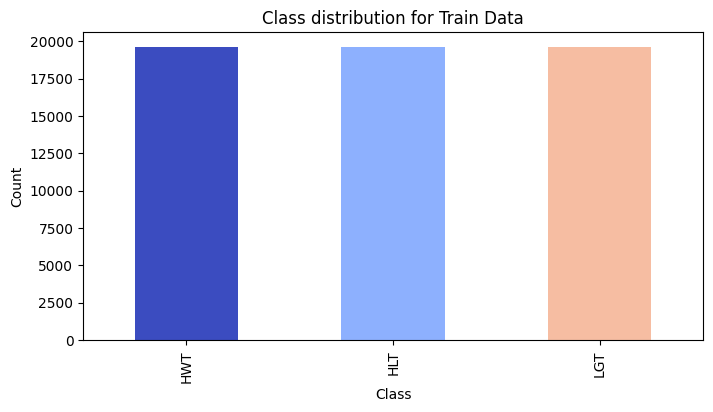

In [56]:
# df = pd.read_csv(f'{BASE_PATH}/train_essays.csv')  # Read CSV file into a DataFrame
df = pd.read_csv(f'{BASE_PATH}/train_data.csv')  # Read CSV file into a DataFrame
# df['label'] = df.generated.copy()
df['label'] = df.Label.copy()
# df['name'] = df.generated.map(CFG.label2name)  # Map answer labels using name-to-label mapping
df['name'] = df.Label.map(CFG.label2name)  # Map answer labels using name-to-label mapping

# Display information about the train data
print("# Train Data: {:,}".format(len(df)))
print("# Sample:")
display(df.head(2))

# Show distribution of answers using a bar plot
plt.figure(figsize=(8, 4))
df.name.value_counts().plot.bar(color=[cmap(0.0), cmap(0.25), cmap(0.65), cmap(0.9), cmap(1.0)])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class distribution for Train Data")
plt.show()

## External Datasets

# External Data: 58,902
# Sample:


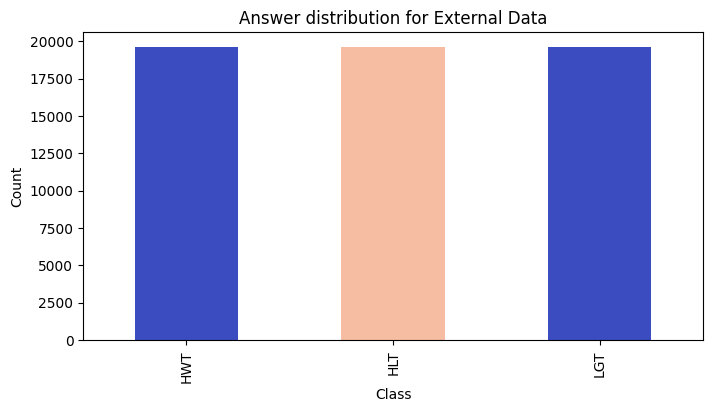

In [57]:
# Load external data
# ext_df1 = pd.read_csv('./kaggle/input/daigt-proper-train-dataset/train_drcat_04.csv')
# ext_df2 = pd.read_csv('./kaggle/input/argugpt/argugpt.csv')[['id','text','model']]

# ext_df2.rename(columns={'model':'source'}, inplace=True)
# ext_df2['label'] = 1

# ext_df = pd.concat([
#     ext_df1[ext_df1.source=='persuade_corpus'].sample(10000),
#     ext_df1[ext_df1.source!='persuade_corpus'],
# #     ext_df2,
# ])

ext_df = pd.read_csv('./data/train_data.csv')
ext_df["label"]=ext_df["Label"]
ext_df["text"]=ext_df["Text"]

# ext_real_df = ext_df[['id', 'text']].copy()
# ext_real_df['label']  = 0

# ext_fake_df = ext_df[['id', 'source_text']].copy()
# ext_fake_df.rename(columns={"source_text":"text"}, inplace=True)
# ext_fake_df['label']  = 1

# ext_df = pd.concat([ext_real_df, ext_fake_df], axis=0)
ext_df['name'] = ext_df.label.map(CFG.label2name)

# Display information about the external data
print("# External Data: {:,}".format(len(ext_df)))
print("# Sample:")
ext_df.head(2)

# Show distribution of answers using a bar plot
plt.figure(figsize=(8, 4))
ext_df.name.value_counts().plot.bar(color=[cmap(0.0), cmap(0.65)])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Answer distribution for External Data")
plt.show()

## Combine External and Train Data

In [58]:
df = ext_df.copy().reset_index(drop=True) # pd.concat([ext_df, df], axis=0)
df.head()

,ID,Text,Label,label,text,name
0,GPT4-News-Rewrite-ID-2003_HWT,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,0,0,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,HWT
1,GPT4-News-Rewrite-ID-2003_HLT,广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...,1,1,广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...,HLT
2,GPT4-News-Rewrite-ID-2003_LGT,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,2,2,偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...,LGT
3,GPT4-News-Rewrite-ID-2001_HWT,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,0,0,编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...,HWT
4,GPT4-News-Rewrite-ID-2001_HLT,在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...,1,1,在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...,HLT


# 🔪 | Data Split

In the code snippet provided below, we will divide the existing **train** data into folds using a stratification of `label` column.

In [59]:
from sklearn.model_selection import StratifiedKFold  # Import package

skf = StratifiedKFold(n_splits=CFG.num_folds, shuffle=True, random_state=CFG.seed)  # Initialize K-Fold

df = df.reset_index(drop=True)  # Reset dataframe index

# df['stratify'] = df.label.astype(str)+df.source.astype(str)
df['stratify'] = df.label.astype(str)+df.name.astype(str)

df["fold"] = -1  # New 'fold' column

# Assign folds using StratifiedKFold
for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['stratify'])):
    df.loc[val_idx, 'fold'] = fold

# Display label distribution for each fold
# df.groupby(["fold", "name", "source"]).size()
df.groupby(["fold", "name", "stratify"]).size()

fold  name  stratify
0     HLT   1HLT        3927
      HWT   0HWT        3927
      LGT   2LGT        3927
1     HLT   1HLT        3927
      HWT   0HWT        3927
      LGT   2LGT        3927
2     HLT   1HLT        3927
      HWT   0HWT        3927
      LGT   2LGT        3926
3     HLT   1HLT        3926
      HWT   0HWT        3927
      LGT   2LGT        3927
4     HLT   1HLT        3927
      HWT   0HWT        3926
      LGT   2LGT        3927
dtype: int64

读取 csv 后立刻检查：

In [60]:
print(df.columns)
print(df.head())
print(df.isnull().sum())

Index(['ID', 'Text', 'Label', 'label', 'text', 'name', 'stratify', 'fold'], dtype='object')
                              ID  \
0  GPT4-News-Rewrite-ID-2003_HWT   
1  GPT4-News-Rewrite-ID-2003_HLT   
2  GPT4-News-Rewrite-ID-2003_LGT   
3  GPT4-News-Rewrite-ID-2001_HWT   
4  GPT4-News-Rewrite-ID-2001_HLT   

                                                Text  Label  label  \
0  偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...      0      0   
1  广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...      1      1   
2  偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...      2      2   
3  编者按：教育培训的市场方面，做地推是一个重要的渠道，作者结合自己的实战经验，为教育培训行业的...      0      0   
4  在教育培训领域，有效的市场推广策略是吸引学生和家长的关键。一位资深市场专家分享了他的实战经验...      1      1   

                                                text name stratify  fold  
0  偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动手称走路...  HWT     0HWT     1  
1  广州市一名男子因涉嫌盗窃并无证驾驶一辆紫色BRT公交车而被警方逮捕。据警方报告，8月18日下...  HLT     1HLT     3  
2  偷公交车的嫌疑人。被偷走的紫色公交车。警方监控视频里发现被偷公交车行踪。趁司机换班动

In [61]:
df["text"] = df["text"].fillna("").astype(str)

# 📖 | Meta Data 
* `{test|train}_essays.csv`
    * `id` - A unique identifier for each essay.
    * `prompt_id` - Identifies the prompt the essay was written in response to.
    * `text` - The essay text itself.
    * `generated` - Whether the essay was written by a student (0) or generated by an LLM (1). This field is the target and is not present in test_essays.csv.
* **sample_submission.csv** - is the valid sample submission.

## Test Data

In [62]:
# test_df = pd.read_csv(f'{BASE_PATH}/test_essays.csv')  # Read CSV file into a DataFrame
test_df = pd.read_csv(f'{BASE_PATH}/testp1_data.csv')  # Read CSV file into a DataFrame
# Display information about the train data
print("# Test Data: {:,}".format(len(test_df)))
print("# Sample:")
display(test_df.head(2))

# Test Data: 3,600
# Sample:


,ID,Text,Label
0,testp1-0,义乌景升工艺品有限公司：高品质油画定制专家，为您的空间增添艺术魅力在追求生活品质的今天，油画...,-1
1,testp1-1,《法医学杂志》，2020年2月，第36卷，第1期 1 案例 1.1 简要案情 患者常某，男性...,-1


In [63]:
# test_df = pd.read_csv(f'{BASE_PATH}/test_essays.csv')  # Read CSV file into a DataFrame
test_df_1 = pd.read_csv(f'{BASE_PATH}/testp2_data.csv')  # Read CSV file into a DataFrame
# Display information about the train data
print("# Test Data: {:,}".format(len(test_df_1)))
print("# Sample:")
display(test_df_1.head(2))

# Test Data: 1,152
# Sample:


,ID,Text,Label
0,testp2-0,邦士度眼镜成功通过ISO9001-2015质量管理体系认证 标志质量管理迈上新台阶近日，广州...,-1
1,testp2-1,法赫里·科鲁蒂尔克 法赫里·萨比特·科鲁蒂尔克（土耳其語：Fahri Sabit Korut...,-1


# 🍽️ | Preprocessing

**What it does:** The preprocessor takes input strings and transforms them into a dictionary (`token_ids`, `padding_mask`) containing preprocessed tensors. This process starts with tokenization, where input strings are converted into sequences of token IDs.

**Why it's important:** Initially, raw text data is complex and challenging for modeling due to its high dimensionality. By converting text into a compact set of tokens, such as transforming `"The quick brown fox"` into `["the", "qu", "##ick", "br", "##own", "fox"]`, we simplify the data. Many models rely on special tokens and additional tensors to understand input. These tokens help divide input and identify padding, among other tasks. Making all sequences the same length through padding boosts computational efficiency, making subsequent steps smoother.

Explore the following pages to access the available preprocessing and tokenizer layers in **KerasNLP**:
- [Preprocessing](https://keras.io/api/keras_nlp/preprocessing_layers/)
- [Tokenizers](https://keras.io/api/keras_nlp/tokenizers/)

In [64]:
# vocab_path = './kaggle/input/keras-nlp-deberta-v3-base-en-vocab-ds/vocab.spm'
# tokenizer= keras_nlp.models.DebertaV3Tokenizer(vocab_path)
# preprocessor= keras_nlp.models.DebertaV3Preprocessor(tokenizer, sequence_length=CFG.sequence_length)

In [65]:
from transformers import AutoTokenizer

In [66]:
tokenizer = AutoTokenizer.from_pretrained(
    "models--microsoft--deberta-v3-base"
)

[transformers] The tokenizer you are loading from 'models--microsoft--deberta-v3-base' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


In [67]:
def tokenize_texts(texts):

    tokens = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=CFG.sequence_length,
        # return_tensors="tf"
        return_tensors="np"
    )

    return {
        "token_ids": tokens["input_ids"],
        "padding_mask": tokens["attention_mask"],
    }

Now, let's examine what the output shape of the preprocessing layer looks like. The output shape of the layer can be represented as $(num\_choices, sequence\_length)$.

In [17]:
# outs = preprocessor(test_df.text.iloc[0])  # Process options for the first row

# # Display the shape of each processed output
# for k, v in outs.items():
#     print(k, ":", v.shape)

We'll use the `preprocessing_fn` function to transform each text option using the `dataset.map(preprocessing_fn)` method.

In [18]:
# def preprocess_fn(text, label=None):
#     text = preprocessor(text)  # Preprocess text
#     return (text, label) if label is not None else text  # Return processed text and label if available

# 🍚 | DataLoader

The code below sets up a robust data flow pipeline using `tf.data.Dataset` for data processing. Notable aspects of `tf.data` include its ability to simplify pipeline construction and represent components in sequences.

To learn more about `tf.data`, refer to this [documentation](https://www.tensorflow.org/guide/data).

In [19]:
# def build_dataset(texts, labels=None, batch_size=32,
#                   cache=False, drop_remainder=True,
#                   augment=False, repeat=False, shuffle=1024):
#     AUTO = tf.data.AUTOTUNE  # AUTOTUNE option
#     slices = (texts,) if labels is None else (texts, labels)  # Create slices
#     ds = tf.data.Dataset.from_tensor_slices(slices)  # Create dataset from slices
#     ds = ds.cache() if cache else ds  # Cache dataset if enabled
#     ds = ds.map(preprocess_fn, num_parallel_calls=AUTO)  # Map preprocessing function
#     ds = ds.repeat() if repeat else ds  # Repeat dataset if enabled
#     opt = tf.data.Options()  # Create dataset options
#     if shuffle: 
#         ds = ds.shuffle(shuffle, seed=CFG.seed)  # Shuffle dataset if enabled
#         opt.experimental_deterministic = False
#     ds = ds.with_options(opt)  # Set dataset options
#     ds = ds.batch(batch_size, drop_remainder=drop_remainder)  # Batch dataset
#     ds = ds.prefetch(AUTO)  # Prefetch next batch
#     return ds  # Return the built dataset

In [68]:
def build_dataset(texts, labels=None,
                  batch_size=32,
                  shuffle=False,
                  repeat=False,
                  drop_remainder=True):

    AUTO = tf.data.AUTOTUNE

    # tokenize first
    x = tokenize_texts(texts)

    if labels is None:

        ds = tf.data.Dataset.from_tensor_slices(x)

    else:

        ds = tf.data.Dataset.from_tensor_slices((
            x,
            labels
        ))

    if shuffle:
        ds = ds.shuffle(1024, seed=CFG.seed)

    if repeat:
        ds = ds.repeat()

    ds = ds.batch(
        batch_size,
        drop_remainder=drop_remainder
    )

    ds = ds.prefetch(AUTO)

    return ds

## Fetch Train/Valid Dataset

The function below generates the training and validation datasets for a given fold.

In [69]:
def get_datasets(fold):

    train_df = df[df.fold != fold].sample(frac=1)

    train_texts = train_df.text.tolist()
    train_labels = train_df.label.tolist()

    train_ds = build_dataset(
        train_texts,
        train_labels,
        batch_size=CFG.batch_size * CFG.replicas,
        shuffle=1024,
        drop_remainder=True,
        repeat=True
    )

    valid_df = df[df.fold == fold].sample(frac=1)

    valid_texts = valid_df.text.tolist()
    valid_labels = valid_df.label.tolist()

    valid_ds = build_dataset(
        valid_texts,
        valid_labels,
        batch_size=min(CFG.batch_size * CFG.replicas, len(valid_df)),
        shuffle=False,
        drop_remainder=False,
        repeat=False
    )

    return (train_ds, train_df), (valid_ds, valid_df)

# 🪄 | Wandb
<img src="https://camo.githubusercontent.com/dd842f7b0be57140e68b2ab9cb007992acd131c48284eaf6b1aca758bfea358b/68747470733a2f2f692e696d6775722e636f6d2f52557469567a482e706e67" width="400" alt="Weights & Biases" />

To monitor the training of my text-based model, I'll make use of **Weights & Biases**. Weights & Biases (W&B) is an MLOps platform that offers experiment tracking, dataset versioning, and model management functionalities, aiding in efficient model development. 

In [70]:
 import wandb  # Import wandb library for experiment tracking

try:
    from kaggle_secrets import UserSecretsClient  # Import UserSecretsClient
    user_secrets = UserSecretsClient()  # Create secrets client instance
    api_key = user_secrets.get_secret("WANDB")  # Get API key from Kaggle secrets
    wandb.login(key=api_key)  # Login to wandb with the API key
    anonymous = None  # Set anonymous mode to None
except:
    anonymous = 'must'  # Set anonymous mode to 'must'
    wandb.login(anonymous=anonymous, relogin=True)  # Login to wandb anonymously and relogin if needed

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: Appending key for api.wandb.ai to your netrc file: /home/wangkongqiang/.netrc


## Logger

The following code cell contains code to log data to WandB. It is noteworthy that the newly released callbacks offer more flexibility in terms of customization, and they are more compact compared to the classic `WandbCallback`, making it easier to use. Here's a brief introduction to them:

* **WandbModelCheckpoint**: This callback saves the model or weights using `tf.keras.callbacks.ModelCheckpoint`. Hence, we can harness the power of the official TensorFlow callback to log even `tf.keras.Model` subclass model in TPU.
* **WandbMetricsLogger**: This callback simply logs all the metrics and losses.
* **WandbEvalCallback**: This one is even more special. We can use it to log the model's prediction after a certain epoch/frequency. We can use it to save segmentation masks, bounding boxes, GradCAM within epochs to check intermediate results and so on.

For more details, please check the [official documentation](https://docs.wandb.ai/ref/python/integrations/keras).

In [71]:
# Initializes the W&B run with a config file and W&B run settings.
def wandb_init(fold):
    config = {k: v for k, v in dict(vars(CFG)).items() if '__' not in k}  # Create config dictionary
    config.update({"fold": int(fold)})  # Add fold to config
    run = wandb.init(project="llm-fake-text",
                     name=f"fold-{fold}|max_seq-{CFG.sequence_length}|model-{CFG.preset}",
                     config=config,
                     group=CFG.comment,
                     save_code=True)
    return run

# Log best result for error analysis
def log_wandb():
    wandb.log({'best_auc': best_auc, 'best_loss': best_loss, 'best_epoch': best_epoch})

# Fetch W&B callbacks
def get_wb_callbacks(fold):
    wb_metr = wandb.keras.WandbMetricsLogger()
    return [wb_metr]  # Return WandB callbacks

# ⚓ | LR Schedule

In [72]:
import math

def get_lr_callback(batch_size=8, mode='cos', epochs=10, plot=False):
    lr_start, lr_max, lr_min = 0.6e-6, 0.5e-6 * batch_size, 0.3e-6
    lr_ramp_ep, lr_sus_ep, lr_decay = 1, 0, 0.75

    def lrfn(epoch):  # Learning rate update function
        if epoch < lr_ramp_ep: lr = (lr_max - lr_start) / lr_ramp_ep * epoch + lr_start
        elif epoch < lr_ramp_ep + lr_sus_ep: lr = lr_max
        elif mode == 'exp': lr = (lr_max - lr_min) * lr_decay**(epoch - lr_ramp_ep - lr_sus_ep) + lr_min
        elif mode == 'step': lr = lr_max * lr_decay**((epoch - lr_ramp_ep - lr_sus_ep) // 2)
        elif mode == 'cos':
            decay_total_epochs, decay_epoch_index = epochs - lr_ramp_ep - lr_sus_ep + 3, epoch - lr_ramp_ep - lr_sus_ep
            phase = math.pi * decay_epoch_index / decay_total_epochs
            lr = (lr_max - lr_min) * 0.5 * (1 + math.cos(phase)) + lr_min
        return lr

    if plot:  # Plot lr curve if plot is True
        plt.figure(figsize=(10, 5))
        plt.plot(np.arange(epochs), [lrfn(epoch) for epoch in np.arange(epochs)], marker='o')
        plt.xlabel('epoch'); plt.ylabel('lr')
        plt.title('LR Scheduler')
        plt.show()

    return keras.callbacks.LearningRateScheduler(lrfn, verbose=False)  # Create lr callback

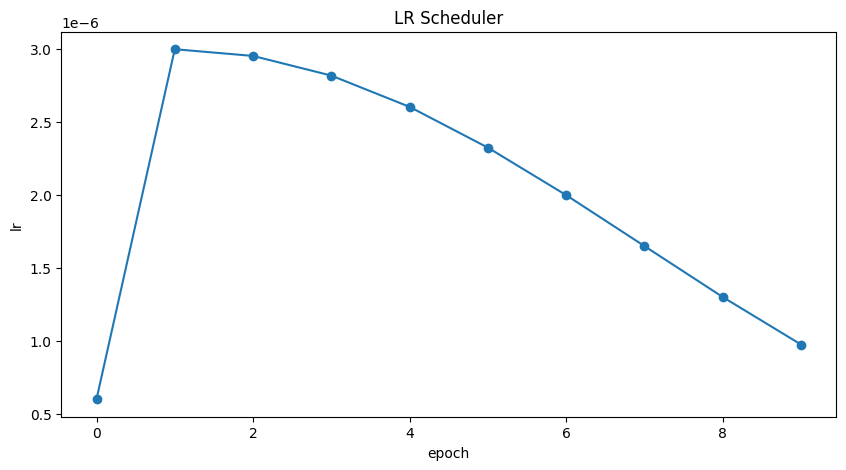

In [73]:
_=get_lr_callback(CFG.batch_size*CFG.replicas, plot=True)

# ☎️ | Callbacks

The function below will gather all the training callbacks, such as `lr_scheduler`, `model_checkpoint`, `wandb_logger`, and etc.

In [74]:
def get_callbacks(fold):
    callbacks = []
    lr_cb = get_lr_callback(CFG.batch_size*CFG.replicas)  # Get lr callback
    ckpt_cb = keras.callbacks.ModelCheckpoint(f'fold{fold}.keras',
                                              monitor='val_auc',
                                              save_best_only=True,
                                              save_weights_only=False,
                                              mode='max')  # Get Model checkpoint callback
    callbacks.extend([lr_cb, ckpt_cb])  # Add lr and checkpoint callbacks

    if CFG.wandb:  # If WandB is enabled
        wb_cbs = get_wb_callbacks(fold)  # Get WandB callbacks
        callbacks.extend(wb_cbs) 
        
    return callbacks  # Return the list of callbacks

## Fetch Train/test Dataset

The function below generates the training and testation datasets for a given fold.

In [75]:
def get_test_dataset(test_df):
    test_texts = test_df.text.tolist()  # Extract testation texts
    
    # Build testation dataset
    # test_ds = build_dataset(test_texts, labels=None,
    #                          batch_size=min(CFG.batch_size*CFG.replicas, len(test_df)), cache=False,
    #                          shuffle=False, drop_remainder=False, repeat=False)
    test_ds = build_dataset(test_texts, labels=None,
                            batch_size=min(CFG.batch_size*CFG.replicas, len(test_df)),
                            shuffle=False, drop_remainder=False, repeat=False)
    
    return test_ds  # Return datasets and dataframes

# 🤖 | Modeling



In [76]:
# def build_model():
#     # Create a DebertaV3Classifier model
#     classifier = keras_nlp.models.DebertaV3Classifier.from_preset(
#         CFG.preset,
#         load_weights=False,
#         preprocessor=None,
#         num_classes=1 # one output per one option, for five options total 5 outputs
#     )
#     inputs = classifier.input
#     logits = classifier(inputs)
        
#     # Compute final output
#     outputs = keras.layers.Activation("sigmoid")(logits)
#     model = keras.Model(inputs, outputs)
#     return model

In [77]:
def build_model():

    # backbone
    backbone = keras_nlp.models.DebertaV3Backbone.from_preset(
        CFG.preset
    )

    # inputs
    token_ids = keras.Input(
        shape=(CFG.sequence_length,),
        dtype=tf.int32,
        name="token_ids"
    )

    padding_mask = keras.Input(
        shape=(CFG.sequence_length,),
        dtype=tf.int32,
        name="padding_mask"
    )

    # forward
    x = backbone({
        "token_ids": token_ids,
        "padding_mask": padding_mask,
    })

    # CLS token
    # x = x[:, 0, :]
    x = keras.layers.Lambda(lambda t: t[:, 0, :])(x)

    # dropout
    x = keras.layers.Dropout(0.2)(x)

    # classifier
    outputs = keras.layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    # build model
    model = keras.Model(
        inputs={
            "token_ids": token_ids,
            "padding_mask": padding_mask,
        },
        outputs=outputs
    )

    # compile
    model.compile(
        # optimizer=keras.optimizers.AdamW(learning_rate=5e-6),
        optimizer=keras.optimizers.Adam(learning_rate=5e-6),
        loss=keras.losses.BinaryCrossentropy(
            label_smoothing=0.02
        ),
        metrics=[
            keras.metrics.AUC(name="auc"),
        ],
        jit_compile=False
    )

    return model

In [78]:
# with strategy.scope
model = build_model()

### Model Summary

In [79]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃ Param # ┃ Connected to         ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask        │ (None, 200)       │       0 │ -                    │
│ (InputLayer)        │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ token_ids           │ (None, 200)       │       0 │ -                    │
│ (InputLayer)        │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ deberta_v3_backbon… │ (None, 200, 768)  │ 183,83… │ padding_mask[0][0],  │
│ (DebertaV3Backbone) │                   │         │ token_ids[0][0]      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ lambda_1 (Lambda)   │ (None, 768)       │       0 │ deberta_v3_backbone… │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ dropout_25          │ (None, 768)       │       0 │ lambda_1[0][0]       │
│ (Dropout)           │                   │         │                      │
├─────────────────────┼───────────────────┼─────────┼──────────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │     769 │ dropout_25[0][0]     │
└─────────────────────┴───────────────────┴─────────┴──────────────────────┘

 Total params: 183,832,321 (701.26 MB)

 Trainable params: 183,832,321 (701.26 MB)

 Non-trainable params: 0 (0.00 B)

### Model Plot

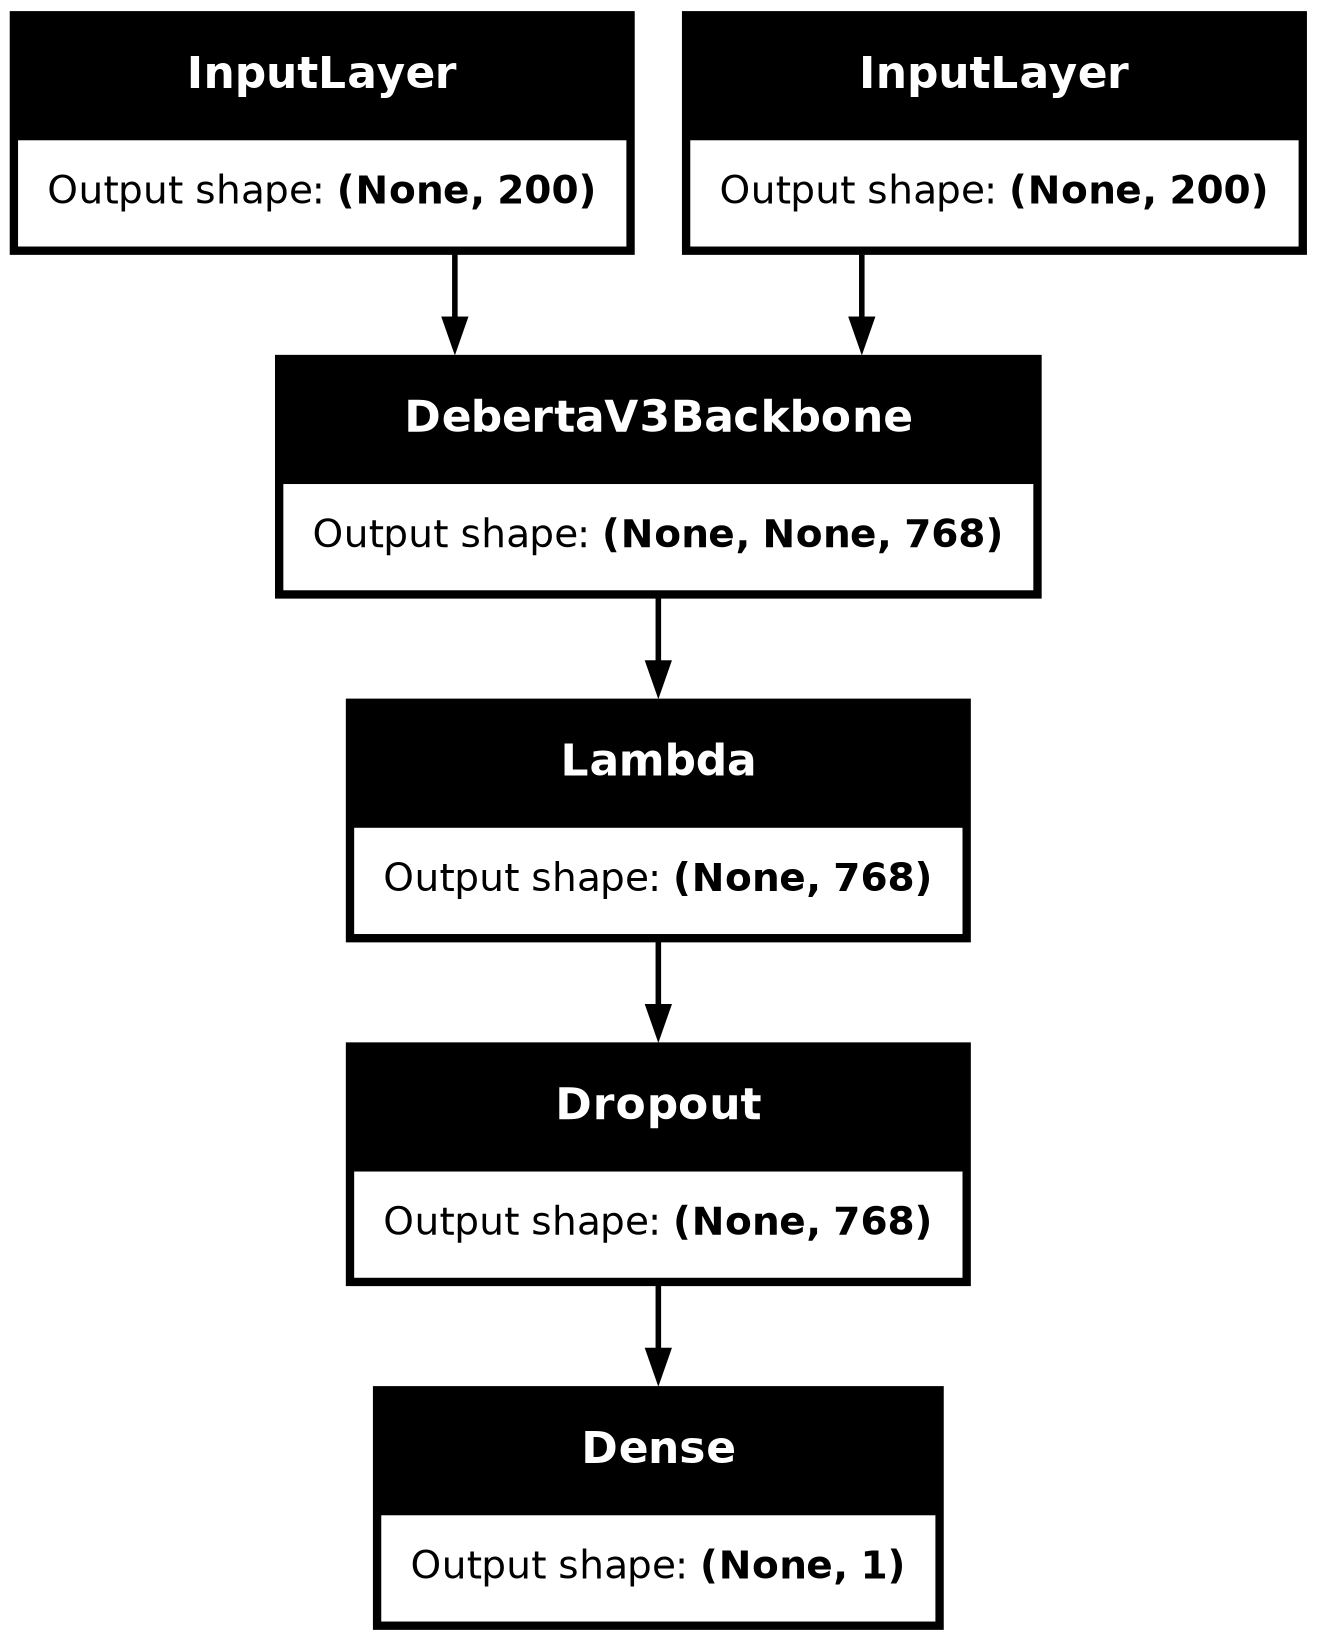

In [80]:
keras.utils.plot_model(model, show_shapes=True)

# 🚂 | Training

In [81]:
for fold in CFG.selected_folds:
    # Initialize Weights and Biases if enabled
    if CFG.wandb:
        run = wandb_init(fold)

    # Get train and validation datasets
    (train_ds, train_df), (valid_ds, valid_df) = get_datasets(fold)
    
    # Get callback functions for training
    callbacks = get_callbacks(fold)

    # Print training information
    print('#' * 50)
    print(f'\tFold: {fold + 1} | Model: {CFG.preset}\n\tBatch Size: {CFG.batch_size * CFG.replicas} | Scheduler: {CFG.scheduler}')
    print(f'\tNum Train: {len(train_df)} | Num Valid: {len(valid_df)}')
    print('#' * 50)
    
    # Clear TensorFlow session and build the model within the strategy scope
    K.clear_session()
    with strategy.scope():
        model = build_model()

    # Start training the model
    history = model.fit(
        train_ds,
        epochs=CFG.epochs,
        validation_data=valid_ds,
        callbacks=callbacks,
        steps_per_epoch=int(len(train_df) / CFG.batch_size / CFG.replicas),
    )
    
    # Find the epoch with the best validation accuracy
    best_epoch = np.argmax(model.history.history['val_auc'])
    best_auc = model.history.history['val_auc'][best_epoch]
    best_loss = model.history.history['val_loss'][best_epoch]

    # Print and display best results
    print(f'\n{"=" * 17} FOLD {fold} RESULTS {"=" * 17}')
    print(f'>>>> BEST Loss  : {best_loss:.3f}\n>>>> BEST AUC   : {best_auc:.3f}\n>>>> BEST Epoch : {best_epoch}')
    print('=' * 50)
    
    # Log best result on Weights and Biases (wandb) if enabled
    if CFG.wandb:
        log_wandb()  # Log results
        wandb.run.finish()  # Finish the run
    #   display(ipd.IFrame(run.url, width=1080, height=720)) # show wandb dashboard
    print("\n\n")

##################################################
	Fold: 1 | Model: deberta_v3_base_en
	Batch Size: 6 | Scheduler: cosine
	Num Train: 47121 | Num Valid: 11781
##################################################
Epoch 1/3
7853/7853 ━━━━━━━━━━━━━━━━━━━━ 38457s 5s/step - auc: 0.5341 - loss: 0.1632 - val_auc: 0.5208 - val_loss: 0.0630 - learning_rate: 6.0000e-07
Epoch 2/3
7853/7853 ━━━━━━━━━━━━━━━━━━━━ 36748s 5s/step - auc: 0.5007 - loss: 0.0343 - val_auc: 0.4994 - val_loss: 0.0690 - learning_rate: 3.0000e-06
Epoch 3/3
7853/7853 ━━━━━━━━━━━━━━━━━━━━ 37016s 5s/step - auc: 0.5020 - loss: 0.0238 - val_auc: 0.4999 - val_loss: 0.0717 - learning_rate: 2.9540e-06

================= FOLD 0 RESULTS =================
>>>> BEST Loss  : 0.063
>>>> BEST AUC   : 0.521
>>>> BEST Epoch : 0


best_auc,▁
best_epoch,▁
best_loss,▁
epoch/auc,█▁▁
epoch/epoch,▁▅█
epoch/learning_rate,▁██
epoch/loss,█▄▁
epoch/val_auc,█▁▁
epoch/val_loss,▁▆█
best_auc,0.52078
best_epoch,0


##################################################
	Fold: 2 | Model: deberta_v3_base_en
	Batch Size: 6 | Scheduler: cosine
	Num Train: 47121 | Num Valid: 11781
##################################################
Epoch 1/3
7853/7853 ━━━━━━━━━━━━━━━━━━━━ 36943s 5s/step - auc: 0.5138 - loss: 0.0820 - val_auc: 0.5082 - val_loss: 0.0616 - learning_rate: 6.0000e-07
Epoch 2/3
7853/7853 ━━━━━━━━━━━━━━━━━━━━ 35706s 5s/step - auc: 0.4938 - loss: 0.0798 - val_auc: 0.5000 - val_loss: 0.0600 - learning_rate: 3.0000e-06
Epoch 3/3
7853/7853 ━━━━━━━━━━━━━━━━━━━━ 35405s 5s/step - auc: 0.4987 - loss: 0.0631 - val_auc: 0.5000 - val_loss: 0.0583 - learning_rate: 2.9540e-06

================= FOLD 1 RESULTS =================
>>>> BEST Loss  : 0.062
>>>> BEST AUC   : 0.508
>>>> BEST Epoch : 0


best_auc,▁
best_epoch,▁
best_loss,▁
epoch/auc,█▁▃
epoch/epoch,▁▅█
epoch/learning_rate,▁██
epoch/loss,▁█▁
epoch/val_auc,█▁▁
epoch/val_loss,█▅▁
best_auc,0.50821
best_epoch,0


## Ckpt processing
For some reason, `keras.models.load_model` requires write access as `/kaggle/input` doesn't have that access it throws error. Workaround is to simply copy the `ckpts` to other directory then load the model.

In [82]:
# Get the checkpoint directory and name
ckpt_dir = CFG.ckpt_dir
ckpt_name = ckpt_dir.split('/')[3]

# Copy the checkpoints to a new directory in the /kaggle directory
# !cp -r {ckpt_dir} ./kaggle/{ckpt_name}

# List all the checkpoint paths in the new directory
new_ckpt_dir = f"./kaggle/{ckpt_name}"
# ckpt_paths = glob(os.path.join(new_ckpt_dir, '*.keras'))
ckpt_paths = glob(os.path.join(new_ckpt_dir, '*.weights.h5'))

print("Total CKPT:", len(ckpt_paths))

Total CKPT: 0


先检查目录：

In [ ]:
# print(new_ckpt_dir)
# !ls -lh {new_ckpt_dir}

# 🧪 | Prediction

## Inference

In [ ]:
# !pip install ipywidgets

In [ ]:
# # Initialize an array to store predictions for each fold
# fold_preds = np.zeros(shape=(len(test_df),), dtype='float32')

# # # Build model
# # model = build_model()

# # Iterate through each checkpoint path
# for ckpt_path in tqdm(ckpt_paths):
#     # Load the pre-trained model from the checkpoint
#     model = keras.models.load_model(
#         ckpt_path,
#         compile=False,
#     )
# #     model.load_weights(ckpt_path)
    
#     # Get the test dataset
#     test_ds = get_test_dataset(test_df)
    
#     # Generate predictions using the model
#     preds = model.predict(
#         test_ds,
#         batch_size=min(CFG.batch_size * CFG.replicas * 2, len(test_df)),  # Set batch size
#         verbose=1
#     )
    
#     # Add predictions to fold_preds and average over checkpoints
#     fold_preds += preds.squeeze() / len(ckpt_paths)
    
#     # Clean up by deleting the model and collecting garbage
#     del model
#     gc.collect()

先检查文件大小（非常重要）

运行：

In [83]:
for p in ckpt_paths:
    print(p, os.path.getsize(p))

In [84]:
ckpt_paths = glob("./kaggle/input/daigt-kerasnlp-ckpt-nlpcc/*.weights.h5")

In [85]:
print(ckpt_paths)

['./kaggle/input/daigt-kerasnlp-ckpt-nlpcc/deberta_fake_text.weights.h5']


In [86]:
print(os.path.getsize(ckpt_paths[0]) / 1024 / 1024)

2104.3596725463867


确认大小正常。

完整修改如下

In [24]:
!pip install tensorflow==2.15.0

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [25]:
!pip install keras==2.15.0

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [26]:
!pip install keras-nlp==0.6.3

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


立刻检查

In [41]:
import keras
print(keras)

<module 'keras' from '/home/wangkongqiang/miniconda3/envs/detect-fake-text/lib/python3.10/site-packages/keras/__init__.py'>


testp1

In [42]:
# Initialize an array to store predictions for each fold
fold_preds = np.zeros(shape=(len(test_df),), dtype='float32')

# Build test dataset once
test_df["text"] = test_df["Text"]
test_ds = get_test_dataset(test_df)

# Iterate through each checkpoint path
for ckpt_path in tqdm(ckpt_paths):

    # Rebuild model architecture
    # model = build_model()
   # FORCE BUILD
    dummy_inputs = {
        "token_ids": tf.zeros((1, CFG.sequence_length), dtype=tf.int32),
        "padding_mask": tf.zeros((1, CFG.sequence_length), dtype=tf.int32),
    }

    _ = model(dummy_inputs)
    
    # Load weights only
    # model.load_weights(ckpt_path)
    # model = keras.models.load_model(
    # "model.keras",
    # safe_mode=False
    # )
    print("ckpt_path:", ckpt_path)
    
    # Generate predictions
    preds = model.predict(
        test_ds,
        batch_size=min(CFG.batch_size * CFG.replicas * 2, len(test_df)),
        verbose=1
    )

    # Average predictions across folds/checkpoints
    fold_preds += preds.squeeze() / len(ckpt_paths)

    # Cleanup
    del model
    gc.collect()

  0%|          | 0/1 [00:00<?, ?it/s]

ckpt_path: ./kaggle/input/daigt-kerasnlp-ckpt-nlpcc/deberta_fake_text.weights.h5
600/600 ━━━━━━━━━━━━━━━━━━━━ 813s 1s/step


## Check Prediction

In [43]:
# Format predictions and true answers
pred_answers = (fold_preds > 0.5).astype(int).squeeze()

# Check 5 Predictions
print("# Predictions\n")
for i in range(3):
    row = test_df.iloc[i]
    text  = row.text
    pred_answer = CFG.label2name[pred_answers[i]]
    print(f"❓ Text {i+1}:\n{text}\n")
    print(f"🤖 Predicted: {pred_answer}\n")
    print("-"*90, "\n")

# Predictions

❓ Text 1:
义乌景升工艺品有限公司：高品质油画定制专家，为您的空间增添艺术魅力在追求生活品质的今天，油画已成为家居装饰、商业空间营造氛围的重要元素。义乌景升工艺品有限公司作为专业的油画供应商，凭借多年行业经验，为全球客户提供高品质的油画产品及定制服务，让艺术之美走进千家万户。一、产品优势：环保材质，匠心工艺我们深知艺术品对生活品质的重要性，因此所有油画产品均采用环保材料制作，确保无毒无害，适合家庭、酒店、办公室等多种场所使用。画芯选用优质画布和高档油画颜料，色彩饱满持久，不易褪色。无论是现代抽象风格，还是古典写实画作，我们都能完美呈现。二、定制服务：满足个性化需求作为专业的油画供应商，我们特别注重客户的个性化需求：1. 尺寸定制：可根据客户要求定制特殊尺寸画作2. 内容定制：支持客户提供图片进行油画创作3. 风格定制：可按照指定艺术风格进行创作4. 批量定制：为商业客户提供大批量订单服务三、常见问题解答1. 关于材质：我们使用进口亚麻画布和高档油画颜料，确保作品品质。画布厚度在2-3mm之间，既保证画面平整度，又便于装裱。2. 关于色差：由于手工绘制特性及显示器差异，成品可能与图片存在轻微色差，这恰恰是手绘作品的独特魅力所在。3. 关于工期：标准订单5-8个工作日完成，加急订单可联系客服安排，最快3天发货。4. 关于物流：我们与多家国际物流公司合作，可根据客户需求选择最合适的运输方式，确保作品安全送达。四、品质保证与服务承诺我们坚持"质量第一，客户至上"的原则：- 严格的质量把控流程- 完善的售后服务体系- 15天无理由退换政策（需保持商品完好）- 专业包装，确保运输安全- 一对一客服咨询，随时解答疑问五、跨境电商合作优势作为跨境电商的专业供应商，我们拥有：- 丰富的出口经验- 多语言产品资料支持- 专业的出口包装方案- 灵活的付款方式- 稳定的供货能力结语：艺术让生活更美好。义乌景升工艺品有限公司期待与全球客户建立长期合作关系，无论是个人收藏还是商业采购，我们都能提供最专业的油画解决方案。现在就联系我们，让专业的艺术顾问为您推荐最适合的产品，或开始您的专属定制之旅！（注：本文约1760字，已涵盖公司介绍、产品特点、服务优势等关键信息，符合SEO优化要求，关键词自然融入文本。）

🤖 Predicted: HLT

------

# 📮 | Submission

In [44]:
# Create a DataFrame to store the submission
# sub_df = test_df[["id"]].copy()
sub_df = test_df[["ID"]].copy()


# Add the formatted predictions to the submission DataFrame
# sub_df["generated"] = fold_preds.squeeze()
sub_df["Label"] = fold_preds.squeeze()

# Save Submission
sub_df.to_csv('submission/testp1/submission-nlpcc.csv',index=False)

# Display the first 2 rows of the submission DataFrame
sub_df.head(2)

,ID,Label
0,testp1-0,0.995634
1,testp1-1,0.995479


In [45]:
print(fold_preds.shape)
print(fold_preds[:10])

(3600,)
[0.9956336  0.99547863 0.99557436 0.9956234  0.9953702  0.99547184
 0.99550354 0.9954922  0.99551255 0.9955862 ]


In [46]:
import json
import numpy as np

# 展平
preds = np.array(fold_preds).squeeze()

prediction = []

for sample_id, p in zip(test_df["ID"], preds):

    # 根据阈值划分类别
    if p < 0.99533:
        label = 0   # HWT

    elif p < 0.99566:
        label = 1   # HLT

    else:
        label = 2 # LGT

    prediction.append({
        "id": sample_id,
        "label": int(label)
    })

# 保存
with open("submission/testp1/prediction.json", "w", encoding="utf-8") as f:
    json.dump(
        prediction,
        f,
        ensure_ascii=False,
        indent=2
    )

print(f"Saved {len(prediction)} samples to prediction.json")

Saved 3600 samples to prediction.json


In [47]:
from collections import Counter

labels = [x["label"] for x in prediction]

print("HWT (0):", Counter(labels)[0])
print("HLT (1):", Counter(labels)[1])
print("LGT (2):", Counter(labels)[2])

HWT (0): 13
HLT (1): 3573
LGT (2): 14


testp2

In [89]:
# Initialize an array to store predictions for each fold
fold_preds = np.zeros(shape=(len(test_df_1),), dtype='float32')

# Build test dataset once
test_df_1["text"] = test_df_1["Text"]
test_ds_1 = get_test_dataset(test_df_1)

# Iterate through each checkpoint path
for ckpt_path in tqdm(ckpt_paths):

    # Rebuild model architecture
    # model = build_model()
   # FORCE BUILD
    dummy_inputs = {
        "token_ids": tf.zeros((1, CFG.sequence_length), dtype=tf.int32),
        "padding_mask": tf.zeros((1, CFG.sequence_length), dtype=tf.int32),
    }

    _ = model(dummy_inputs)
    
    # Load weights only
    # model.load_weights(ckpt_path)
    # model = keras.models.load_model(
    # "model.keras",
    # safe_mode=False
    # )
    print("ckpt_path:", ckpt_path)
    
    # Generate predictions
    preds = model.predict(
        test_ds_1,
        batch_size=min(CFG.batch_size * CFG.replicas * 2, len(test_df)),
        verbose=1
    )

    # Average predictions across folds/checkpoints
    fold_preds += preds.squeeze() / len(ckpt_paths)

    # Cleanup
    # del model
    # gc.collect()

  0%|          | 0/1 [00:00<?, ?it/s]

ckpt_path: ./kaggle/input/daigt-kerasnlp-ckpt-nlpcc/deberta_fake_text.weights.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step


## Check Prediction

In [91]:
# Format predictions and true answers
pred_answers = (fold_preds > 0.5).astype(int).squeeze()

# Check 5 Predictions
print("# Predictions\n")
for i in range(3):
    row = test_df_1.iloc[i]
    text  = row.text
    pred_answer = CFG.label2name[pred_answers[i]]
    print(f"❓ Text {i+1}:\n{text}\n")
    print(f"🤖 Predicted: {pred_answer}\n")
    print("-"*90, "\n")

# Predictions

❓ Text 1:
邦士度眼镜成功通过ISO9001-2015质量管理体系认证 标志质量管理迈上新台阶近日，广州邦士度眼镜有限公司传来喜讯——公司于2017年5月8日顺利通过了ISO9001-2015质量管理体系认证。这一重要成就不仅标志着邦士度在质量管理标准方面达到国内领先水平，也为其未来持续发展奠定了坚实基础。自1999年成立以来，邦士度眼镜始终致力于眼部保护事业，逐步发展为一家集研发、生产与市场营销于一体的集团化企业。作为行业内的知名品牌，邦士度深谙"质量是企业的生命线"这一道理。早在多年前，该公司便首次导入ISO9001质量管理体系，并在此后连续多次通过认证审核，展现了其对质量管理的高度重视和不懈追求。此次通过ISO9001-2015版本的复审，不仅是对邦士度过往努力的认可，更是对其未来发展的鞭策。新版标准强调以客户为中心、基于风险管理以及过程方法的应用，这与邦士度长期以来坚持的理念不谋而合。借助这一先进的国际质量管理体系，邦士度进一步优化了业务流程，提升了运营效率，同时有效识别和控制潜在风险，为消费者提供更优质的产品和服务。据公司内部透露，导入ISO9001标准以来，邦士度已逐步构建起一套完善的标准化经营体系。从产品研发到生产线管理，再到市场推广，每个环节都严格遵循规范化模式，确保产品品质始终如一。这种精益求精的态度使得邦士度在市场上赢得了良好的口碑，也为国产眼镜品牌树立了标杆。邦士度相关负责人表示："通过ISO9001-2015质量管理体系认证是我们发展历程中的一个重要里程碑。但这绝非终点，而是新的起点。"未来，邦士度将继续秉持"科技引领创新、品质赢得信赖"的核心价值观，不断加大研发投入，推动技术创新，满足消费者日益增长的需求。同时，公司还计划进一步拓展国际市场，将中国智造推向全球舞台。业内人士认为，在竞争激烈的视光行业中，邦士度凭借强大的综合实力和稳健的发展步伐，已然成为一股不可忽视的力量。此次获得ISO9001-2015认证，无疑将进一步巩固其市场地位，为品牌的长远发展注入强劲动力。展望未来，邦士度眼镜将继续肩负"守护清晰视界，点亮美好生活"的使命，为更多消费者带来舒适、安全的眼部保护解决方案，书写属于自己的辉煌篇章！

🤖 Predicted: HLT

--------------------------------

# 📮 | Submission

In [92]:
# Create a DataFrame to store the submission
# sub_df = test_df[["id"]].copy()
sub_df = test_df_1[["ID"]].copy()


# Add the formatted predictions to the submission DataFrame
# sub_df["generated"] = fold_preds.squeeze()
sub_df["Label"] = fold_preds.squeeze()

# Save Submission
sub_df.to_csv('submission/testp2/submission-nlpcc.csv',index=False)

# Display the first 2 rows of the submission DataFrame
sub_df.head(2)

,ID,Label
0,testp2-0,0.995586
1,testp2-1,0.995524


In [93]:
print(fold_preds.shape)
print(fold_preds[:10])

(1152,)
[0.99558634 0.9955243  0.9955397  0.995532   0.9955978  0.99558467
 0.99565834 0.9955384  0.9955925  0.99557793]


In [94]:
import json
import numpy as np

# 展平
preds = np.array(fold_preds).squeeze()

prediction = []

for sample_id, p in zip(test_df_1["ID"], preds):

    # 根据阈值划分类别
    if p < 0.99533:
        label = 0   # HWT

    elif p < 0.99566:
        label = 1   # HLT

    else:
        label = 2 # LGT

    prediction.append({
        "id": sample_id,
        "label": int(label)
    })

# 保存
with open("submission/testp2/prediction.json", "w", encoding="utf-8") as f:
    json.dump(
        prediction,
        f,
        ensure_ascii=False,
        indent=2
    )

print(f"Saved {len(prediction)} samples to prediction.json")

Saved 1152 samples to prediction.json


如果想检查三个类别的分布：

In [95]:
from collections import Counter

labels = [x["label"] for x in prediction]

print("HWT (0):", Counter(labels)[0])
print("HLT (1):", Counter(labels)[1])
print("LGT (2):", Counter(labels)[2])

HWT (0): 5
HLT (1): 1142
LGT (2): 5
